In [2]:
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import numpy as np

In [5]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [6]:
import pandas as pd

In [7]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:

df = pd.read_excel(r"C:\Users\Admin\Downloads\loan_approval.xlsx")
print(df)

                 name              city  income  credit_score  loan_amount  \
0        Allison Hill         East Jill  113810           389        39698   
1        Brandon Hall     New Jamesside   44592           729        15446   
2        Rhonda Smith      Lake Roberto   33278           584        11189   
3     Gabrielle Davis  West Melanieview  127196           344        48823   
4        Valerie Gray         Mariastad   66048           496        47174   
...               ...               ...     ...           ...          ...   
1995   James Schaefer         Robertton   92163           770        12251   
1996        Diana Lin         New Frank   38799           635        48259   
1997    Brandon Meyer        East Haley   41957           763        16752   
1998      Jason Price          Adamland  139022           360        24031   
1999     Nicole Brown    New Nathantown   41188           482        31397   

      years_employed  points  loan_approved  
0                

#Q1. Data Loading & Understanding 
a) Load the dataset into Python.  
b) Display the first 5 rows.  
c) Check the shape of the dataset.  
d) Display the data types of each column.  


In [ ]:
df = pd.read_excel(r"C:\Users\Admin\Downloads\loan_approval.xlsx")
print(df)

In [17]:
#
print("First 5 rows:")

df.head()


First 5 rows:


,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [16]:
#
print("Data Shape:")
df.shape

Data Shape:


(2000, 8)

In [18]:
print("Data types:")
df.dtypes


Data types:


name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object

#Q2. Data Cleaning 
a) Check for missing values in the dataset.  


In [19]:
df.isnull().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [ ]:
#b) Handle missing values appropriately. 
Ans- There is no missing values in this daatset

In [ ]:
#c) Identify categorical columns present in the dataset. 

In [21]:
df.columns

Index(['name', 'city', 'income', 'credit_score', 'loan_amount',
       'years_employed', 'points', 'loan_approved'],
      dtype='object')

In [ ]:
categoricals_columns=["name","city","loan_approved"]

#Q3. Exploratory Data Analysis (EDA) 
a) Plot the distribution of the target variable.
  b) Analyze the relationship between one numerical feature and the target variable. 
 c) Analyze the relationship between Years of Employment and the target variable. 


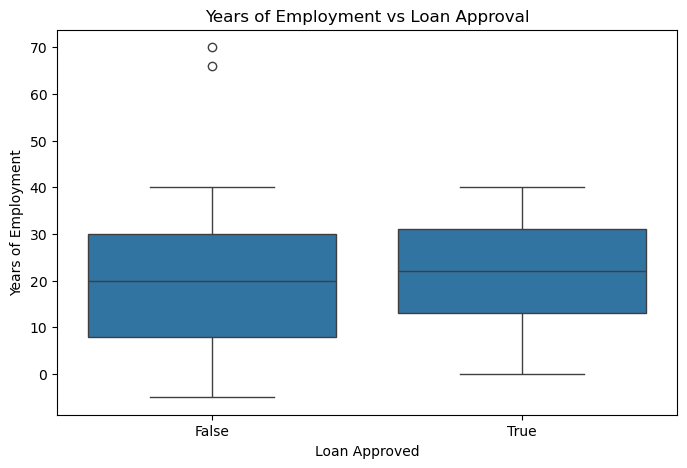

In [22]:
#a) Plot the distribution of the target variable.
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="loan_approved", y="years_employed")
plt.title("Years of Employment vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Years of Employment")
plt.show()

In [23]:
#Calculate the average:
print(df.groupby("loan_approved")["years_employed"].mean())

loan_approved
False    19.425513
True     21.829352
Name: years_employed, dtype: float64


In [ ]:
#
Interpretation

Approved applicants have a slightly higher average number of years employed than rejected applicants.

Not approved ≈ 19.43 years
Approved ≈ 21.83 years

Therefore, years of employment has a positive but comparatively weaker relationship with loan approval.

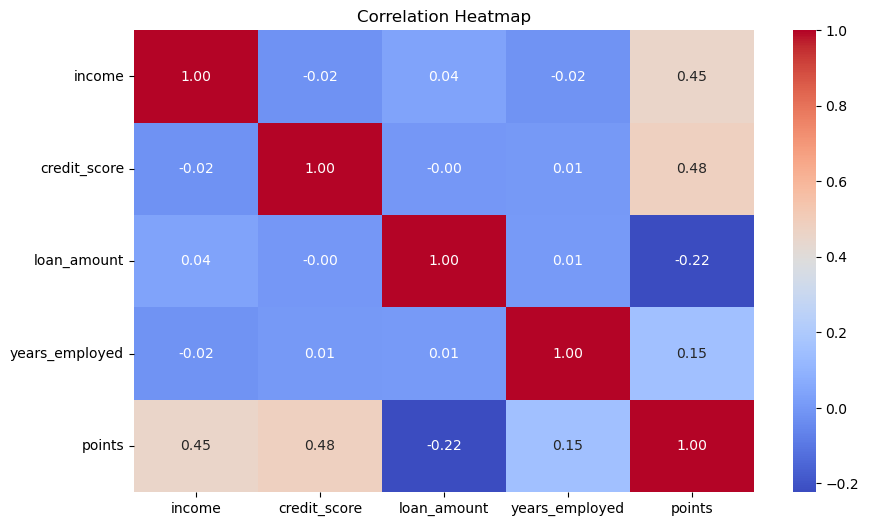

In [24]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

# Q4. Outlier Detection and Treatment

a) Detect outliers in numerical columns using the IQR method. 
b) Treat outliers using capping techniques

In [25]:
numeric_columns = [
    "income",
    "credit_score",
    "loan_amount",
    "years_employed",
    "points"
]

In [26]:
for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(column)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    print("-" * 50)

income
Lower Bound: -26909.0
Upper Bound: 208305.0
Number of Outliers: 0
--------------------------------------------------
credit_score
Lower Bound: 8.5
Upper Bound: 1140.5
Number of Outliers: 3
--------------------------------------------------
loan_amount
Lower Bound: -24198.875
Upper Bound: 74328.125
Number of Outliers: 0
--------------------------------------------------
years_employed
Lower Bound: -21.5
Upper Bound: 62.5
Number of Outliers: 2
--------------------------------------------------
points
Lower Bound: 7.5
Upper Bound: 107.5
Number of Outliers: 0
--------------------------------------------------


In [ ]:
#b) Treat outliers using capping techniques

In [27]:
df_clean = df.copy()

for column in numeric_columns:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean[column] = df_clean[column].clip(
        lower_bound,
        upper_bound
    )

print("Outliers capped successfully.")

Outliers capped successfully.


In [28]:
df_clean[numeric_columns].describe()

,income,credit_score,loan_amount,years_employed,points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,574.546250,25308.503000,20.476500,56.680000
std,34487.874907,162.442674,14207.320147,11.852993,18.638033
min,30053.000000,11.000000,1022.000000,-5.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,716.000000,37380.500000,31.000000,70.000000
max,149964.000000,1140.500000,49999.000000,62.500000,100.000000


#Q5. Convert target variables into numerical format suitable for model building and drop unnecessary columns.
Ans. The loan_approved column is Boolean (True/False), so convert it to 1/0.

Also, name and city are not required for this Logistic Regression model.

In [29]:
# code
df_clean["loan_approved"] = df_clean["loan_approved"].astype(int)

# Drop unnecessary columns
df_clean = df_clean.drop(
    columns=["name", "city"]
)

df_clean.head()

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389.0,39698,27.0,50,0
1,44592,729.0,15446,28.0,55,0
2,33278,584.0,11189,13.0,45,0
3,127196,344.0,48823,29.0,50,0
4,66048,496.0,47174,4.0,25,0


In [30]:
df_clean.dtypes

income              int64
credit_score      float64
loan_amount         int64
years_employed    float64
points              int64
loan_approved       int64
dtype: object

In [ ]:
#Q6. Feature Selection and Data Splitting
a) Separate independent variables (X) and dependent variable (y). 


In [31]:
# Independent variables
X = df_clean.drop(columns=["loan_approved"])

# Dependent variable
y = df_clean["loan_approved"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 5)
y shape: (2000,)


#b) Split the dataset into training and testing sets. 

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1600, 5)
Testing data: (400, 5)


#Q7. Apply feature scaling to the dataset using StandardScaler. 

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

#
explainantion for fit_transform=Why use fit_transform() on training data and only transform() on testing data?

Because the test data should not influence the calculation of the scaling parameters.

Scaling completed successfully.


#Q8. Logistic Regression Model Building
a) Train a Logistic Regression model. 


In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


#b) Predict the output for test data. 

In [35]:
y_pred = model.predict(X_test_scaled)

print("Predicted values:")
print(y_pred[:20])

Predicted values:
[1 0 1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 0]


In [ ]:
#Probability predictions:

In [36]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Prediction probabilities:")
print(y_prob[:10])

Prediction probabilities:
[7.71071761e-01 2.28948757e-06 9.94590445e-01 9.99956713e-01
 2.18862902e-06 1.00000000e+00 9.82318023e-03 9.99998630e-01
 1.30136277e-01 2.17204433e-06]


Regression Equation

Logistic Regression equation:

In [ ]:
#

log(
1−p
p
	​

)=β
0
	​

+β
1
	​

X
1
	​

+β
2
	​

X
2
	​

+...+β
n
	​

X
n


In [37]:
#
For this dataset, the model uses:

Income
Credit Score
Loan Amount
Years Employed
Points

Display the coefficients:
print("Intercept:", model.intercept_[0])

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients)

Intercept: -0.40514791663426347
          Feature  Coefficient
0          income     0.006430
1    credit_score     0.590723
2     loan_amount    -0.265406
3  years_employed     0.039697
4          points    10.238151


Interpretation of Coefficients

In [38]:
# Calculate odds ratios
odds_ratios = np.exp(model.coef_[0])

coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0],
    "Odds_Ratio": odds_ratios
})

coefficient_table

,Feature,Coefficient,Odds_Ratio
0,income,0.006430,1.006451
1,credit_score,0.590723,1.805294
2,loan_amount,-0.265406,0.766894
3,years_employed,0.039697,1.040495
4,points,10.238151,27949.392466


In [ ]:
#Interpretation
Income: Positive coefficient → higher income slightly increases the probability of approval.
Credit Score: Positive coefficient → higher credit score increases the likelihood of loan approval.
Loan Amount: Negative coefficient → larger loan amounts are associated with lower approval probability, holding other variables constant.
Years Employed: Positive coefficient → more employment experience slightly increases approval probability.
Points: Strong positive coefficient → higher points are strongly associated with loan approval.

The Points variable has the strongest positive effect in this model, followed by Credit Score.

#Q9. Model Evaluation – Confusion Matrix
a) Generate the confusion matrix. 


In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[224   0]
 [  0 176]]


In [ ]:
# Results
Therefore:

True Negative (TN) = 224
False Positive (FP) = 0
False Negative (FN) = 0
True Positive (TP) = 176

#Visualize

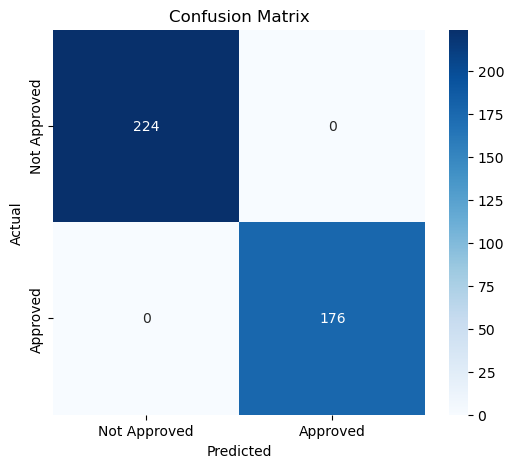

In [40]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Approved", "Approved"],
    yticklabels=["Not Approved", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#b) Interpret the results. 

In [ ]:
# Interpretation

The model correctly classified all observations in the test dataset.

224 applications were correctly predicted as not approved.
176 applications were correctly predicted as approved.
There were 0 false positives.
There were 0 false negatives.

Thus, the model achieved perfect classification on this particular test split.

In [41]:
#additinal 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       224
           1       1.00      1.00      1.00       176

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



#Q10. Model Evaluation – ROC Curve & AUC
a) Plot the ROC curve. 


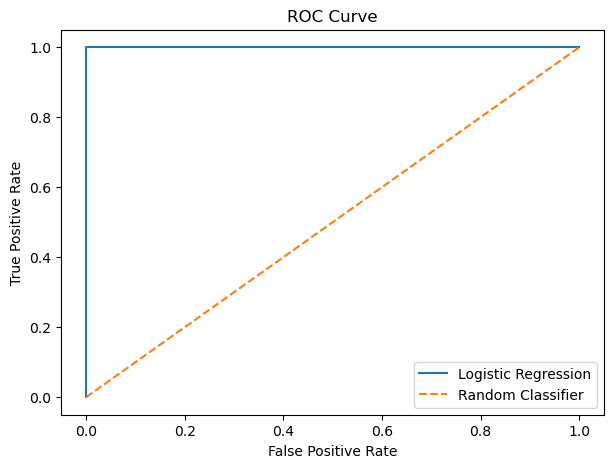

In [43]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate probabilities
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#b) Calculate the AUC score.


In [45]:
print("For this dataset and the specified train/test split:")
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

For this dataset and the specified train/test split:
AUC Score: 1.0


In [ ]:
#
Interpretation

An AUC of 1.00 indicates that the model perfectly separates approved and non-approved loan applications on this test set.

AUC = 1.0 → Perfect classifier
AUC = 0.5 → Random classifier
AUC < 0.5 → Worse than random

In [ ]:
# conclusion

The Logistic Regression model was developed to predict whether a loan application would be approved or not. Exploratory Data Analysis showed that credit score and points have strong relationships with loan approval, while years of employment has a comparatively weaker positive relationship. Outliers were detected using the IQR method and treated using capping. The categorical target variable was converted into numerical form, unnecessary columns were removed, and the numerical features were standardized using StandardScaler. The Logistic Regression model achieved 100% accuracy, precision, recall, and F1-score, with an AUC of 1.00 on the test dataset. The confusion matrix also showed zero false-positive and false-negative predictions. Therefore, the model performed extremely well on this dataset, although performance should ideally be validated using cross-validation or another independent dataset before being used in a real financial institution.